In [15]:
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import label, binary_opening, binary_closing, binary_fill_holes

In [16]:
project_root = Path("..").resolve()

train_dir = project_root / "data" / "train"
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

subject = "subj001"
subject_dir = train_dir / subject

image_path = subject_dir / f"{subject}_image.nii.gz"
artifact_path = subject_dir / f"{subject}_artifact.nii.gz"

print("Image exists:", image_path.exists())
print("Artifact exists:", artifact_path.exists())

Image exists: True
Artifact exists: True


In [17]:
img = nib.load(image_path)
I = img.get_fdata()

artifact_img = nib.load(artifact_path)
A = artifact_img.get_fdata()

print("MRI shape:", I.shape)
print("Artifact shape:", A.shape)
print("Artifact values:", np.unique(A))

MRI shape: (192, 224, 192)
Artifact shape: (192, 224, 192)
Artifact values: [0. 1.]


In [18]:
def normalize_volume(I):
    """
    Normalize MRI volume using mean/std.
    """
    return (I - np.mean(I)) / (np.std(I) + 1e-8)


def dice_score(pred, truth):
    """
    Compute Dice similarity between predicted mask and ground truth mask.
    """
    pred = pred.astype(bool)
    truth = truth.astype(bool)

    intersection = np.logical_and(pred, truth).sum()
    denom = pred.sum() + truth.sum()

    if denom == 0:
        return 1.0

    return 2 * intersection / denom


def keep_largest_components(mask, min_size=100, max_components=3):
    """
    Keep the largest connected components in a binary mask.
    """
    labeled, num = label(mask)

    if num == 0:
        return np.zeros_like(mask, dtype=bool)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0

    component_ids = np.argsort(sizes)[::-1]

    out = np.zeros_like(mask, dtype=bool)
    kept = 0

    for comp_id in component_ids:
        if comp_id == 0:
            continue
        if sizes[comp_id] < min_size:
            continue

        out |= (labeled == comp_id)
        kept += 1

        if kept >= max_components:
            break

    return out

In [19]:
def predict_artifact_mask(I, hemisphere="right", debug=False):
    """
    Automatic classical valve artifact detector.
    Uses MRI + hemisphere metadata.
    Does NOT use ground-truth artifact mask.
    """

    I_norm = normalize_volume(I)

    # -----------------------------
    # 1. Rough head mask
    # -----------------------------
    head_thresh = np.percentile(I_norm, 30)
    head_mask = I_norm > head_thresh

    head_mask = binary_closing(head_mask, iterations=2)
    head_mask = binary_fill_holes(head_mask)

    # -----------------------------
    # 2. Dark voxels inside head
    # -----------------------------
    dark_thresh = np.percentile(I_norm[head_mask], 15)
    dark_mask = I_norm < dark_thresh

    # -----------------------------
    # 3. Spatial search box
    # -----------------------------
    x = np.arange(I.shape[0])[:, None, None]
    y = np.arange(I.shape[1])[None, :, None]
    z = np.arange(I.shape[2])[None, None, :]

    # Use hemisphere metadata
    if hemisphere == "right":
        side_mask = (x > int(0.55 * I.shape[0])) & (x < int(0.95 * I.shape[0]))
    else:
        side_mask = (x > int(0.05 * I.shape[0])) & (x < int(0.45 * I.shape[0]))

    # Avoid extreme front/back edges and top/bottom junk
    y_mask = (y > int(0.35 * I.shape[1])) & (y < int(0.80 * I.shape[1]))
    z_mask = (z > int(0.35 * I.shape[2])) & (z < int(0.70 * I.shape[2]))

    search_region = side_mask & y_mask & z_mask

    # -----------------------------
    # 4. Candidate mask
    # -----------------------------
    candidate = head_mask & dark_mask & search_region

    candidate = binary_opening(candidate, iterations=1)
    candidate = binary_closing(candidate, iterations=1)

    # -----------------------------
    # 5. Connected components
    # -----------------------------
    labeled, num = label(candidate)

    if num == 0:
        if debug:
            print("No candidate components found.")
        return np.zeros_like(I, dtype=bool)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0

    best_score = -np.inf
    best_component = None

    for comp_id in range(1, num + 1):
        comp = labeled == comp_id
        size = sizes[comp_id]

        # Filter unreasonable sizes
        if size < 50 or size > 25000:
            continue

        coords = np.argwhere(comp)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)

        dx = x_max - x_min + 1
        dy = y_max - y_min + 1
        dz = z_max - z_min + 1

        # Avoid giant sheets/long structures
        if dx > 90 or dy > 90 or dz > 70:
            continue

        bbox_volume = dx * dy * dz
        fill_ratio = size / bbox_volume
        mean_intensity = I_norm[comp].mean()

        # Score: prefer dark, compact, reasonable-size components
        score = (-mean_intensity) + 2.0 * fill_ratio + 0.00005 * size

        if score > best_score:
            best_score = score
            best_component = comp

    if best_component is None:
        if debug:
            print("No component passed filters.")
        return np.zeros_like(I, dtype=bool)

        # -----------------------------
    # 6. Use candidate component as prediction seed
    # -----------------------------
    from scipy.ndimage import binary_dilation

    pred = best_component.copy()

    # Clean/fill the selected component slightly
    pred = binary_closing(pred, iterations=2)

    # Grow it a little because candidate is usually smaller than artifact
    pred = binary_dilation(pred, iterations=3)

    if debug:
        coords = np.argwhere(best_component)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)

        print("Hemisphere:", hemisphere)
        print("Dark threshold:", dark_thresh)
        print("Best score:", best_score)
        print("Best component size:", best_component.sum())
        print("Best component bbox:", (x_min, x_max, y_min, y_max, z_min, z_max))
        print("Final voxels:", pred.sum())

    return pred

In [22]:


M_pred = predict_artifact_mask(I, hemisphere=hemisphere, debug=True)

print("Pred voxels:", M_pred.sum())
print("GT voxels:", A.sum())
print("Overlap:", np.logical_and(M_pred > 0, A > 0).sum())
print("Dice:", dice_score(M_pred, A))

NameError: name 'hemisphere' is not defined

In [ ]:
import json

json_path = subject_dir / f"{subject}.json"

with open(json_path, "r") as f:
    meta = json.load(f)

meta


{'subject_id': 'subj010',
 'hemisphere': 'right',
 'catheter_length_mm': 48.31,
 'spacing_zyx_mm': [1.0, 1.0, 1.0]}

In [23]:
import json

results = []

for subject_dir in sorted(train_dir.iterdir())[:10]:
    if not subject_dir.is_dir():
        continue

    subject = subject_dir.name

    image_path = subject_dir / f"{subject}_image.nii.gz"
    artifact_path = subject_dir / f"{subject}_artifact.nii.gz"
    json_path = subject_dir / f"{subject}.json"

    img = nib.load(image_path)
    I = img.get_fdata()

    A = nib.load(artifact_path).get_fdata()

    with open(json_path, "r") as f:
        meta = json.load(f)

    hemisphere = meta["hemisphere"]

    M_pred = predict_artifact_mask(I, hemisphere=hemisphere, debug=False)

    dice = dice_score(M_pred, A)
    overlap = np.logical_and(M_pred > 0, A > 0).sum()

    results.append({
        "subject": subject,
        "hemisphere": hemisphere,
        "dice": dice,
        "pred_voxels": M_pred.sum(),
        "gt_voxels": A.sum(),
        "overlap": overlap
    })

    print(
        f"{subject} | hemi={hemisphere} | "
        f"Dice={dice:.4f} | overlap={overlap} | "
        f"pred={M_pred.sum()} | gt={A.sum()}"
    )

subj001 | hemi=right | Dice=0.0000 | overlap=0 | pred=585 | gt=11995.0
subj002 | hemi=right | Dice=0.7287 | overlap=9987 | pred=13337 | gt=14073.0
subj003 | hemi=right | Dice=0.3695 | overlap=3861 | pred=4209 | gt=16692.0
subj004 | hemi=right | Dice=0.7098 | overlap=7311 | pred=10689 | gt=9912.0
subj005 | hemi=right | Dice=0.0000 | overlap=0 | pred=970 | gt=8523.0
subj006 | hemi=right | Dice=0.0000 | overlap=0 | pred=943 | gt=10558.0
subj007 | hemi=right | Dice=0.0000 | overlap=0 | pred=493 | gt=12960.0
subj008 | hemi=right | Dice=0.0000 | overlap=0 | pred=478 | gt=13104.0
subj009 | hemi=right | Dice=0.0000 | overlap=0 | pred=607 | gt=11173.0
subj010 | hemi=right | Dice=0.0000 | overlap=0 | pred=710 | gt=14425.0



subj005
Hemisphere: right
Dark threshold: -0.7160524271895906
Best score: 0.9449488115215375
Best component size: 126
Crop box: (np.int64(143), np.int64(191), np.int64(147), np.int64(198), np.int64(102), np.int64(152))
Local threshold: -0.7106502669062753
Final voxels: 39804
Dice: 0.0
Overlap: 0


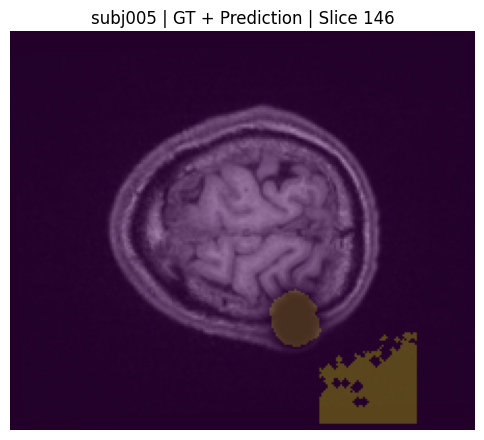


subj006
Hemisphere: right
Dark threshold: -0.6193645505907129
Best score: 1.125836966083448
Best component size: 161
Crop box: (np.int64(156), 192, np.int64(141), np.int64(190), np.int64(103), np.int64(153))
Local threshold: -0.6157844323346242
Final voxels: 29757
Dice: 0.0
Overlap: 0


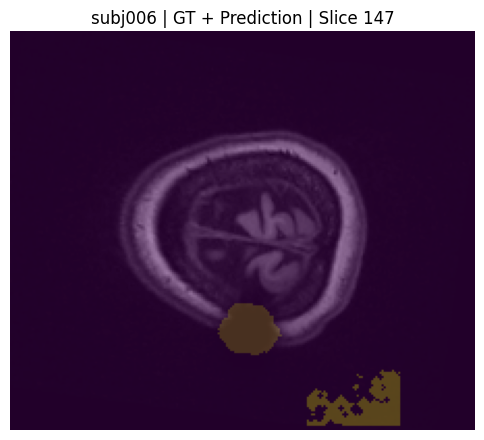


subj008
Hemisphere: right
Dark threshold: -0.6409281446138958
Best score: 1.345280876210945
Best component size: 68
Crop box: (np.int64(153), 192, np.int64(142), np.int64(188), np.int64(96), np.int64(142))
Local threshold: -0.6348788387734468
Final voxels: 24462
Dice: 0.0
Overlap: 0


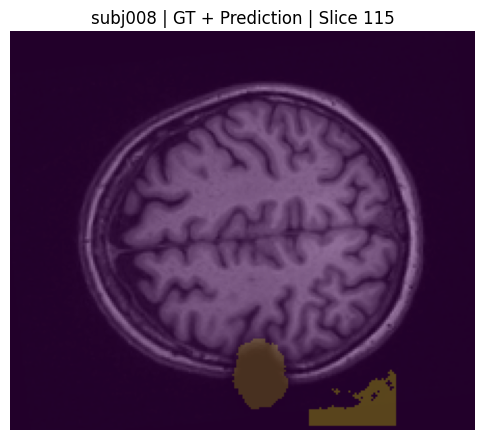


subj009
Hemisphere: right
Dark threshold: -0.6107614698094619
Best score: 1.0062139726756247
Best component size: 96
Crop box: (np.int64(153), 192, np.int64(152), np.int64(198), np.int64(106), np.int64(153))
Local threshold: -0.6108896261505758
Final voxels: 22020
Dice: 0.0
Overlap: 0


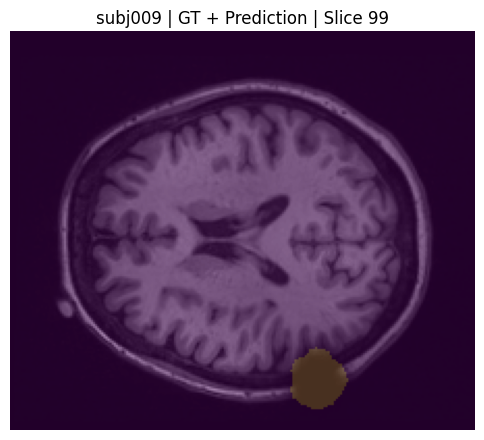

In [ ]:
failed_subjects = ["subj005", "subj006", "subj008", "subj009"]

for subject in failed_subjects:
    subject_dir = train_dir / subject

    image_path = subject_dir / f"{subject}_image.nii.gz"
    artifact_path = subject_dir / f"{subject}_artifact.nii.gz"
    json_path = subject_dir / f"{subject}.json"

    img = nib.load(image_path)
    I = img.get_fdata()
    A = nib.load(artifact_path).get_fdata()

    with open(json_path, "r") as f:
        meta = json.load(f)

    hemisphere = meta["hemisphere"]

    print("\n======================")
    print(subject)

    M_pred = predict_artifact_mask(I, hemisphere=hemisphere, debug=True)

    print("Dice:", dice_score(M_pred, A))
    print("Overlap:", np.logical_and(M_pred > 0, A > 0).sum())

    artifact_slices = np.where(A.sum(axis=(0, 1)) > 0)[0]
    mid_slice = artifact_slices[len(artifact_slices)//2]

    plt.figure(figsize=(6, 6))
    plt.imshow(I[:, :, mid_slice], cmap="gray")
    plt.imshow(A[:, :, mid_slice], alpha=0.3)
    plt.imshow(M_pred[:, :, mid_slice], alpha=0.3)
    plt.axis("off")
    plt.title(f"{subject} | GT + Prediction | Slice {mid_slice}")
    plt.show()

In [ ]:
def get_candidate_components(I, hemisphere="right", max_candidates=5):
    I_norm = normalize_volume(I)

    head_thresh = np.percentile(I_norm, 30)
    head_mask = I_norm > head_thresh
    head_mask = binary_closing(head_mask, iterations=2)
    head_mask = binary_fill_holes(head_mask)

    dark_thresh = np.percentile(I_norm[head_mask], 15)
    dark_mask = I_norm < dark_thresh

    x = np.arange(I.shape[0])[:, None, None]
    y = np.arange(I.shape[1])[None, :, None]
    z = np.arange(I.shape[2])[None, None, :]

    if hemisphere == "right":
        side_mask = (x > int(0.50 * I.shape[0])) & (x < int(0.98 * I.shape[0]))
    else:
        side_mask = (x > int(0.02 * I.shape[0])) & (x < int(0.50 * I.shape[0]))

    y_mask = (y > int(0.25 * I.shape[1])) & (y < int(0.85 * I.shape[1]))
    z_mask = (z > int(0.25 * I.shape[2])) & (z < int(0.80 * I.shape[2]))

    candidate = head_mask & dark_mask & side_mask & y_mask & z_mask

    candidate = binary_opening(candidate, iterations=1)
    candidate = binary_closing(candidate, iterations=1)

    labeled, num = label(candidate)
    sizes = np.bincount(labeled.ravel())

    candidates = []

    for comp_id in range(1, num + 1):
        comp = labeled == comp_id
        size = sizes[comp_id]

        if size < 50 or size > 30000:
            continue

        coords = np.argwhere(comp)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)

        dx = x_max - x_min + 1
        dy = y_max - y_min + 1
        dz = z_max - z_min + 1

        if dx > 100 or dy > 100 or dz > 80:
            continue

        bbox_volume = dx * dy * dz
        fill_ratio = size / bbox_volume
        mean_intensity = I_norm[comp].mean()

        score = (-mean_intensity) + 2.0 * fill_ratio + 0.00005 * size

        candidates.append({
            "component_id": comp_id,
            "mask": comp,
            "score": score,
            "size": size,
            "bbox": (x_min, x_max, y_min, y_max, z_min, z_max),
            "mean_intensity": mean_intensity,
            "fill_ratio": fill_ratio
        })

    candidates = sorted(candidates, key=lambda c: c["score"], reverse=True)

    return candidates[:max_candidates]

In [27]:
from scipy.ndimage import binary_dilation

for subject_dir in sorted(train_dir.iterdir())[:10]:
    if not subject_dir.is_dir():
        continue

    subject = subject_dir.name
    image_path = subject_dir / f"{subject}_image.nii.gz"
    artifact_path = subject_dir / f"{subject}_artifact.nii.gz"
    json_path = subject_dir / f"{subject}.json"

    img = nib.load(image_path)
    I = img.get_fdata()
    A = nib.load(artifact_path).get_fdata()

    with open(json_path, "r") as f:
        meta = json.load(f)

    hemisphere = meta["hemisphere"]

    candidates = get_candidate_components(I, hemisphere=hemisphere, max_candidates=5)

    print("\n", subject, "hemisphere:", hemisphere)

    for idx, cand in enumerate(candidates):
        pred = binary_closing(cand["mask"], iterations=2)
        pred = binary_dilation(pred, iterations=3)

        dice = dice_score(pred, A)
        overlap = np.logical_and(pred, A > 0).sum()

        print(
            f"candidate {idx+1}: "
            f"dice={dice:.4f}, overlap={overlap}, "
            f"size={cand['size']}, score={cand['score']:.3f}, bbox={cand['bbox']}"
        )


 subj001 hemisphere: right
candidate 1: dice=0.0000, overlap=0, size=110, score=1.210, bbox=(np.int64(173), np.int64(181), np.int64(74), np.int64(80), np.int64(49), np.int64(55))
candidate 2: dice=0.0000, overlap=0, size=172, score=1.153, bbox=(np.int64(173), np.int64(179), np.int64(164), np.int64(170), np.int64(73), np.int64(88))
candidate 3: dice=0.0000, overlap=0, size=101, score=1.115, bbox=(np.int64(124), np.int64(132), np.int64(183), np.int64(189), np.int64(145), np.int64(152))
candidate 4: dice=0.0000, overlap=0, size=78, score=1.102, bbox=(np.int64(152), np.int64(159), np.int64(185), np.int64(189), np.int64(121), np.int64(130))
candidate 5: dice=0.0000, overlap=0, size=88, score=1.078, bbox=(np.int64(171), np.int64(176), np.int64(164), np.int64(173), np.int64(66), np.int64(73))

 subj002 hemisphere: right
candidate 1: dice=0.2663, overlap=10468, size=28522, score=2.316, bbox=(np.int64(121), np.int64(179), np.int64(113), np.int64(189), np.int64(83), np.int64(152))
candidate 2: 

In [28]:
failed_subjects = ["subj001", "subj007", "subj008", "subj009", "subj010"]

for subject in failed_subjects:
    subject_dir = train_dir / subject

    image_path = subject_dir / f"{subject}_image.nii.gz"
    artifact_path = subject_dir / f"{subject}_artifact.nii.gz"
    json_path = subject_dir / f"{subject}.json"

    img = nib.load(image_path)
    I = img.get_fdata()
    A = nib.load(artifact_path).get_fdata()

    with open(json_path, "r") as f:
        meta = json.load(f)

    hemisphere = meta["hemisphere"]

    candidates = get_candidate_components(I, hemisphere=hemisphere, max_candidates=20)

    print("\n", subject)

    found_any = False

    for idx, cand in enumerate(candidates):
        pred = binary_closing(cand["mask"], iterations=2)
        pred = binary_dilation(pred, iterations=3)

        dice = dice_score(pred, A)
        overlap = np.logical_and(pred, A > 0).sum()

        if overlap > 0:
            found_any = True
            print(
                f"candidate {idx+1}: dice={dice:.4f}, overlap={overlap}, "
                f"size={cand['size']}, score={cand['score']:.3f}, bbox={cand['bbox']}"
            )

    if not found_any:
        print("No top-20 candidate overlaps artifact.")


 subj001
No top-20 candidate overlaps artifact.

 subj007
No top-20 candidate overlaps artifact.

 subj008
No top-20 candidate overlaps artifact.

 subj009
No top-20 candidate overlaps artifact.

 subj010
No top-20 candidate overlaps artifact.


In [29]:
subject = "subj001"
subject_dir = train_dir / subject

image_path = subject_dir / f"{subject}_image.nii.gz"
artifact_path = subject_dir / f"{subject}_artifact.nii.gz"
json_path = subject_dir / f"{subject}.json"

img = nib.load(image_path)
I = img.get_fdata()
A = nib.load(artifact_path).get_fdata()

with open(json_path, "r") as f:
    meta = json.load(f)

hemisphere = meta["hemisphere"]

I_norm = normalize_volume(I)

head_thresh = np.percentile(I_norm, 30)
head_mask = I_norm > head_thresh
head_mask = binary_closing(head_mask, iterations=2)
head_mask = binary_fill_holes(head_mask)

x = np.arange(I.shape[0])[:, None, None]
y = np.arange(I.shape[1])[None, :, None]
z = np.arange(I.shape[2])[None, None, :]

if hemisphere == "right":
    side_mask = (x > int(0.50 * I.shape[0])) & (x < int(0.98 * I.shape[0]))
else:
    side_mask = (x > int(0.02 * I.shape[0])) & (x < int(0.50 * I.shape[0]))

y_mask = (y > int(0.25 * I.shape[1])) & (y < int(0.85 * I.shape[1]))
z_mask = (z > int(0.25 * I.shape[2])) & (z < int(0.80 * I.shape[2]))

search_region = side_mask & y_mask & z_mask

In [30]:
print("Artifact voxels:", A.sum())

print("Artifact inside head mask:", np.logical_and(A > 0, head_mask).sum())
print("Artifact inside side mask:", np.logical_and(A > 0, side_mask).sum())
print("Artifact inside y mask:", np.logical_and(A > 0, y_mask).sum())
print("Artifact inside z mask:", np.logical_and(A > 0, z_mask).sum())
print("Artifact inside full search region:", np.logical_and(A > 0, search_region).sum())

Artifact voxels: 11995.0
Artifact inside head mask: 6169
Artifact inside side mask: 11995
Artifact inside y mask: 11995
Artifact inside z mask: 11995
Artifact inside full search region: 11995


In [31]:
for p in [10, 15, 20, 25, 30, 35, 40, 45, 50]:
    dark_thresh = np.percentile(I_norm[head_mask], p)
    dark_mask = I_norm < dark_thresh

    candidate_raw = head_mask & dark_mask & search_region

    overlap_raw = np.logical_and(candidate_raw, A > 0).sum()

    candidate_opened = binary_opening(candidate_raw, iterations=1)
    candidate_opened = binary_closing(candidate_opened, iterations=1)

    overlap_opened = np.logical_and(candidate_opened, A > 0).sum()

    print(
        f"p={p:2d} | dark_thresh={dark_thresh:.3f} | "
        f"raw_overlap={overlap_raw} | opened_overlap={overlap_opened} | "
        f"raw_voxels={candidate_raw.sum()} | opened_voxels={candidate_opened.sum()}"
    )

p=10 | dark_thresh=-0.711 | raw_overlap=275 | opened_overlap=18 | raw_voxels=33189 | opened_voxels=1694
p=15 | dark_thresh=-0.705 | raw_overlap=379 | opened_overlap=44 | raw_voxels=56188 | opened_voxels=9523
p=20 | dark_thresh=-0.700 | raw_overlap=554 | opened_overlap=70 | raw_voxels=82415 | opened_voxels=27797
p=25 | dark_thresh=-0.694 | raw_overlap=722 | opened_overlap=108 | raw_voxels=112899 | opened_voxels=61769
p=30 | dark_thresh=-0.687 | raw_overlap=927 | opened_overlap=138 | raw_voxels=147384 | opened_voxels=105754
p=35 | dark_thresh=-0.678 | raw_overlap=1162 | opened_overlap=173 | raw_voxels=185289 | opened_voxels=155217
p=40 | dark_thresh=-0.663 | raw_overlap=1464 | opened_overlap=259 | raw_voxels=224987 | opened_voxels=204951
p=45 | dark_thresh=-0.634 | raw_overlap=1924 | opened_overlap=578 | raw_voxels=265138 | opened_voxels=254093
p=50 | dark_thresh=-0.496 | raw_overlap=3526 | opened_overlap=2843 | raw_voxels=308799 | opened_voxels=295919


In [34]:
def sliding_window_candidates(I, hemisphere="right", window=(50, 50, 40), stride=10, top_k=10):
    I_norm = normalize_volume(I)

    wx, wy, wz = window

    x_start = int(0.50 * I.shape[0]) if hemisphere == "right" else int(0.02 * I.shape[0])
    x_end   = int(0.98 * I.shape[0]) if hemisphere == "right" else int(0.50 * I.shape[0])

    y_start = int(0.45 * I.shape[1])
    y_end   = int(0.85 * I.shape[1])

    z_start = int(0.25 * I.shape[2])
    z_end   = int(0.80 * I.shape[2])

    candidates = []

    for x1 in range(x_start, x_end - wx, stride):
        for y1 in range(y_start, y_end - wy, stride):
            for z1 in range(z_start, z_end - wz, stride):
                x2 = x1 + wx
                y2 = y1 + wy
                z2 = z1 + wz

                crop = I_norm[x1:x2, y1:y2, z1:z2]

                # Local threshold inside this crop
                thresh = np.percentile(crop, 45)
                dark_fraction = np.mean(crop < thresh)

                # Lower median = more suspiciously dark
                median_intensity = np.median(crop)

                # Score favors darker local windows
                dark_fraction = np.mean(crop < np.percentile(crop, 25))

                score = (
                    -median_intensity
                    + 2.0 * dark_fraction
                    )

                candidates.append({
                    "bbox": (x1, x2, y1, y2, z1, z2),
                    "score": score,
                    "median": median_intensity,
                    "dark_fraction": dark_fraction
                })

    candidates = sorted(candidates, key=lambda c: c["score"], reverse=True)
    return candidates[:top_k]

In [35]:
cands = sliding_window_candidates(I, hemisphere=hemisphere, top_k=10)

for idx, c in enumerate(cands):
    x1, x2, y1, y2, z1, z2 = c["bbox"]

    box_mask = np.zeros_like(A, dtype=bool)
    box_mask[x1:x2, y1:y2, z1:z2] = True

    artifact_in_box = np.logical_and(box_mask, A > 0).sum()

    print(
        f"{idx+1}: bbox={c['bbox']}, score={c['score']:.3f}, "
        f"artifact_in_box={artifact_in_box}"
    )

1: bbox=(136, 186, 130, 180, 108, 148), score=1.171, artifact_in_box=4844
2: bbox=(136, 186, 120, 170, 108, 148), score=1.138, artifact_in_box=5760
3: bbox=(136, 186, 130, 180, 98, 138), score=1.105, artifact_in_box=9190
4: bbox=(136, 186, 110, 160, 108, 148), score=1.011, artifact_in_box=5760
5: bbox=(136, 186, 100, 150, 108, 148), score=0.982, artifact_in_box=5758
6: bbox=(136, 186, 120, 170, 98, 138), score=0.894, artifact_in_box=11154
7: bbox=(136, 186, 130, 180, 88, 128), score=0.859, artifact_in_box=9974
8: bbox=(136, 186, 110, 160, 98, 138), score=0.774, artifact_in_box=11154
9: bbox=(126, 176, 130, 180, 108, 148), score=0.736, artifact_in_box=4444
10: bbox=(136, 186, 100, 150, 98, 138), score=0.715, artifact_in_box=11134


In [36]:
best_bbox = cands[5]["bbox"]  # candidate 6

x1, x2, y1, y2, z1, z2 = best_bbox

crop = I_norm[x1:x2, y1:y2, z1:z2]
crop_A = A[x1:x2, y1:y2, z1:z2]

for p in [30, 35, 40, 45, 50, 55]:
    thresh = np.percentile(crop, p)
    crop_pred = crop < thresh

    pred = np.zeros_like(A, dtype=bool)
    pred[x1:x2, y1:y2, z1:z2] = crop_pred

    print(
        f"p={p}, thresh={thresh:.3f}, "
        f"dice={dice_score(pred, A):.4f}, "
        f"overlap={np.logical_and(pred, A > 0).sum()}, "
        f"voxels={pred.sum()}"
    )

p=30, thresh=-0.692, dice=0.3006, overlap=6311, voxels=30000
p=35, thresh=-0.682, dice=0.2790, overlap=6555, voxels=35000
p=40, thresh=-0.664, dice=0.2661, overlap=6917, voxels=40000
p=45, thresh=-0.574, dice=0.2869, overlap=8177, voxels=45000
p=50, thresh=-0.394, dice=0.3099, overlap=9606, voxels=50000
p=55, thresh=-0.233, dice=0.3096, overlap=10372, voxels=55000


In [37]:
from scipy.ndimage import label, binary_closing, binary_opening

best_bbox = cands[5]["bbox"]  # candidate 6
x1, x2, y1, y2, z1, z2 = best_bbox

crop = I_norm[x1:x2, y1:y2, z1:z2]

for p in [45, 50, 55]:
    thresh = np.percentile(crop, p)
    crop_pred = crop < thresh

    crop_pred = binary_opening(crop_pred, iterations=1)
    crop_pred = binary_closing(crop_pred, iterations=2)

    labeled, num = label(crop_pred)
    sizes = np.bincount(labeled.ravel())

    for keep_n in [1, 2, 3, 5]:
        if num == 0:
            continue

        sizes_temp = sizes.copy()
        sizes_temp[0] = 0

        largest_ids = np.argsort(sizes_temp)[::-1][:keep_n]

        crop_keep = np.zeros_like(crop_pred, dtype=bool)
        for comp_id in largest_ids:
            if comp_id == 0:
                continue
            crop_keep |= labeled == comp_id

        pred = np.zeros_like(A, dtype=bool)
        pred[x1:x2, y1:y2, z1:z2] = crop_keep

        print(
            f"p={p}, keep_n={keep_n}, "
            f"dice={dice_score(pred, A):.4f}, "
            f"overlap={np.logical_and(pred, A > 0).sum()}, "
            f"voxels={pred.sum()}"
        )

p=45, keep_n=1, dice=0.3420, overlap=7799, voxels=33607
p=45, keep_n=2, dice=0.3420, overlap=7799, voxels=33607
p=45, keep_n=3, dice=0.3420, overlap=7799, voxels=33607
p=45, keep_n=5, dice=0.3420, overlap=7799, voxels=33607
p=50, keep_n=1, dice=0.3803, overlap=9151, voxels=36127
p=50, keep_n=2, dice=0.3797, overlap=9151, voxels=36209
p=50, keep_n=3, dice=0.3792, overlap=9151, voxels=36274
p=50, keep_n=5, dice=0.3790, overlap=9151, voxels=36298
p=55, keep_n=1, dice=0.3741, overlap=9825, voxels=40531
p=55, keep_n=2, dice=0.3735, overlap=9825, voxels=40610
p=55, keep_n=3, dice=0.3734, overlap=9825, voxels=40628
p=55, keep_n=5, dice=0.3733, overlap=9825, voxels=40648
